In [15]:
from typing import List, Tuple
import time

import matplotlib.pyplot as plt
import pandas as pd
import kenlm
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import Levenshtein
from torch.utils.data import Dataset
from wav2vec2decoder import Wav2Vec2Decoder
from jiwer import wer, cer

In [3]:
test_samples = [
        ("examples/sample1.wav", "IF YOU ARE GENEROUS HERE IS A FITTING OPPORTUNITY FOR THE EXERCISE OF YOUR MAGNANIMITY IF YOU ARE PROUD HERE AM I YOUR RIVAL READY TO ACKNOWLEDGE MYSELF YOUR DEBTOR FOR AN ACT OF THE MOST NOBLE FORBEARANCE"),
        ("examples/sample2.wav", "AND IF ANY OF THE OTHER COPS HAD PRIVATE RACKETS OF THEIR OWN IZZY WAS UNDOUBTEDLY THE MAN TO FIND IT OUT AND USE THE INFORMATION WITH A BEAT SUCH AS THAT EVEN GOING HALVES AND WITH ALL THE GRAFT TO THE UPPER BRACKETS HE'D STILL BE ABLE TO MAKE HIS PILE IN A MATTER OF MONTHS"),
        ("examples/sample3.wav", "GUESS A MAN GETS USED TO ANYTHING HELL MAYBE I CAN HIRE SOME BUMS TO SIT AROUND AND WHOOP IT UP WHEN THE SHIPS COME IN AND BILL THIS AS A REAL OLD MARTIAN DEN OF SIN"),
        ("examples/sample4.wav", "IT WAS A TUNE THEY HAD ALL HEARD HUNDREDS OF TIMES SO THERE WAS NO DIFFICULTY IN TURNING OUT A PASSABLE IMITATION OF IT TO THE IMPROVISED STRAINS OF I DIDN'T WANT TO DO IT THE PRISONER STRODE FORTH TO FREEDOM"),
        ("examples/sample5.wav", "MARGUERITE TIRED OUT WITH THIS LONG CONFESSION THREW HERSELF BACK ON THE SOFA AND TO STIFLE A SLIGHT COUGH PUT UP HER HANDKERCHIEF TO HER LIPS AND FROM THAT TO HER EYES"),
        ("examples/sample6.wav", "AT THIS TIME ALL PARTICIPANTS ARE IN A LISTEN ONLY MODE"),
        ("examples/sample7.wav", "THE INCREASE WAS MAINLY ATTRIBUTABLE TO THE NET INCREASE IN THE AVERAGE SIZE OF OUR FLEETS"),
        ("examples/sample8.wav", "OPERATING SURPLUS IS A NON CAP FINANCIAL MEASURE WHICH IS DEFINED AS FULLY IN OUR PRESS RELEASE"),
    ]

In [4]:
audio_path, true_transcription = test_samples[0]
audio_input, sr = torchaudio.load(audio_path)
print(true_transcription)

IF YOU ARE GENEROUS HERE IS A FITTING OPPORTUNITY FOR THE EXERCISE OF YOUR MAGNANIMITY IF YOU ARE PROUD HERE AM I YOUR RIVAL READY TO ACKNOWLEDGE MYSELF YOUR DEBTOR FOR AN ACT OF THE MOST NOBLE FORBEARANCE


# Dataset

In [5]:
class LibriSpeechDataset(Dataset):
    def __init__(self, csv_path):
        self.data = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        waveform, sample_rate = torchaudio.load(row['path'])
        text = row['text']
        return waveform, sample_rate, text

In [6]:
dataset = LibriSpeechDataset('data/librispeech_test_other/manifest.csv')

# Test

In [7]:
decoder = Wav2Vec2Decoder(beam_width=3)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [8]:
inputs = decoder.processor(audio_input[0], sampling_rate=sr,  return_tensors="pt")
with torch.no_grad():
    probs = decoder.model(**inputs).logits

In [9]:
#ctc base
decoder.greedy_decode(probs)

'if you are generous here is a fitting opportunity for the exercise of your magnanimity if you are proud here am i your rival reter to acknowledge myself your deptor for an act of most noble forbearance'

In [10]:
# ctc beam
decoder.beam_search_decode(probs)

'if you are generous here is a fitting opportunity for the exercise of your magnanimity if you are proud here am i your rival rether to cknowledge myself your deptor for an act of most noble forbearance'

In [11]:
def evaluate(decoder, dataset, method="greedy"):
    all_refs, all_hyps = [], []
    
    start = time.time()
    with torch.no_grad():
        for waveform, sample_rate, ref_text in dataset:
            inputs = decoder.processor(
                waveform.squeeze().numpy(),
                sampling_rate=sample_rate,
                return_tensors="pt"
            )
            logits = decoder.model(**inputs).logits

            if method == "greedy":
                hyp = decoder.greedy_decode(logits)
            elif method == "beam":
                hyp = decoder.beam_search_decode(logits)

            all_refs.append(ref_text.lower().strip())
            all_hyps.append(hyp.lower().strip())

    elapsed = time.time() - start
    return wer(all_refs, all_hyps), cer(all_refs, all_hyps), elapsed

In [12]:
# Greedy
decoder = Wav2Vec2Decoder(beam_width=1)
greedy_wer, greedy_cer, greedy_time = evaluate(decoder, dataset, method="greedy")

# Beam k=3
decoder = Wav2Vec2Decoder(beam_width=3)
beam_wer, beam_cer, beam_time = evaluate(decoder, dataset, method="beam")

print("=" * 50)
print("Greedy")
print("=" * 50)
print(f" WER: {greedy_wer*100:.2f}% (реф = 10.4%)")
print(f" CER: {greedy_cer*100:.2f}% (реф = 3.5%)")

print()
print("=" * 50)
print("Beam search (k=3)")
print("=" * 50)
print(f" WER: {beam_wer*100:.2f}% (реф = 9.9%)")
print(f" CER: {beam_cer*100:.2f}% (реф = 3.4%)")


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Greedy
 WER: 6.77% (реф = 10.4%)
 CER: 2.34% (реф = 3.5%)

Beam search (k=3)
 WER: 6.70% (реф = 9.9%)
 CER: 2.31% (реф = 3.4%)


In [13]:
results = []
for k in [1, 3, 10, 50]:
    decoder = Wav2Vec2Decoder(beam_width=k)
    w, c, t = evaluate(decoder, dataset, method="beam")
    results.append({"beam_width": k, "WER": w*100, "CER": c*100, "time_sec": t})
    print(f"k={k:>2}  WER={w*100:.2f}%  CER={c*100:.2f}%  time={t:.1f}s")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


k= 1  WER=6.72%  CER=2.33%  time=83.2s


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


...

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


k=10  WER=6.75%  CER=2.30%  time=140.0s


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


k=50  WER=6.72%  CER=2.30%  time=411.4s


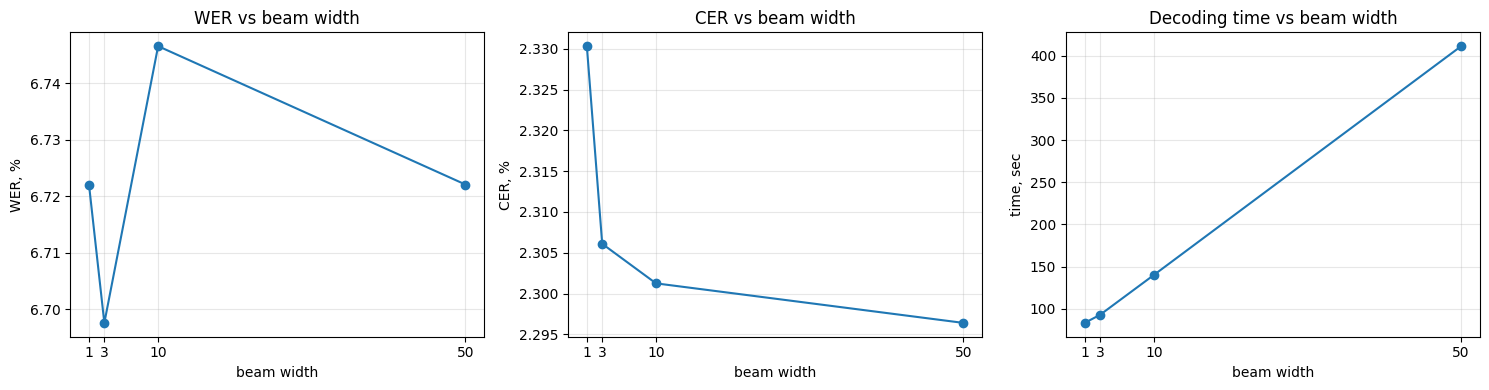

In [17]:
ks = [r["beam_width"] for r in results]
wers = [r["WER"] for r in results]
cers = [r["CER"] for r in results]
times = [r["time_sec"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ks, wers, marker="o")
axes[0].set_title("WER vs beam width")
axes[0].set_xlabel("beam width")
axes[0].set_ylabel("WER, %")
axes[0].set_xticks(ks)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ks, cers, marker="o")
axes[1].set_title("CER vs beam width")
axes[1].set_xlabel("beam width")
axes[1].set_ylabel("CER, %")
axes[1].set_xticks(ks)
axes[1].grid(True, alpha=0.3)

axes[2].plot(ks, times, marker="o")
axes[2].set_title("Decoding time vs beam width")
axes[2].set_xlabel("beam width")
axes[2].set_ylabel("time, sec")
axes[2].set_xticks(ks)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
temp_results = []

for T in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    decoder = Wav2Vec2Decoder(beam_width=5, temperature=T)
    w, c, t = evaluate(decoder, dataset, method="greedy")
    temp_results.append({"temperature": T, "WER": w*100, "CER": c*100})
    print(f"T={T}  WER={w*100:.2f}%  CER={c*100:.2f}%")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


T=0.5  WER=6.77%  CER=2.34%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


...

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


T=1.5  WER=6.77%  CER=2.34%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


T=2.0  WER=6.77%  CER=2.34%


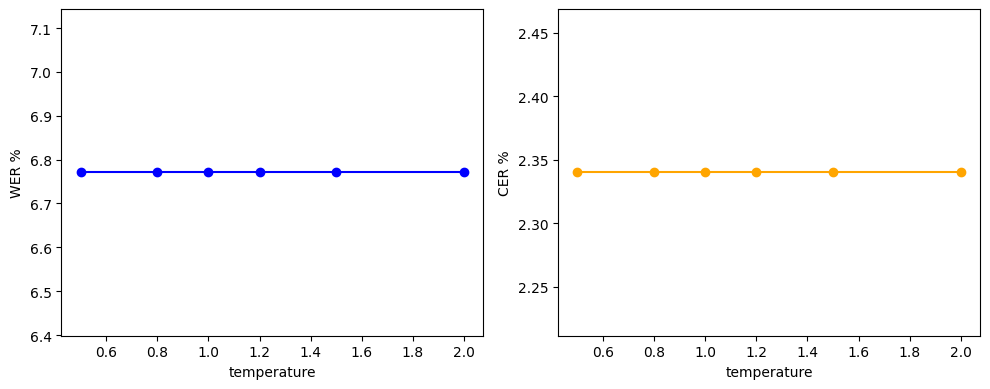

In [38]:
temps = [r["temperature"] for r in temp_results]
wers_t = [r["WER"] for r in temp_results]
cers_t = [r["CER"] for r in temp_results]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(temps, wers_t, marker="o", color="blue")
axes[0].set_xlabel("temperature")
axes[0].set_ylabel("WER %")

axes[1].plot(temps, cers_t, marker="o", color="orange")
axes[1].set_xlabel("temperature")
axes[1].set_ylabel("CER %")

plt.tight_layout()
plt.show()